# Bayesian Renewal Forecasting: 4-Week Forecast Examples

This notebook demonstrates how to use the `spatial_bayes_renewal` package to forecast infectious disease dynamics for the next 4 weeks (28 days). We'll show examples of both:
- **ClassicalForecaster**: Single-region model
- **SpatialForecaster**: Multi-region model with spatial effects

We'll generate synthetic data, fit Bayesian renewal models, and visualize 4-week forecasts for hospital admissions and wastewater concentrations.

## 1. Import Required Libraries

In [ ]:
import sys
import os

# Add parent directory to path so we can import spatial_bayes_renewal
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
from datetime import datetime, timedelta
from scipy.stats import lognorm, poisson
import networkx as nx
import warnings
import jax.numpy as jnp
warnings.filterwarnings('ignore')

# Import forecasting models and reusable visualization helpers
from spatial_bayes_renewal import (
    ClassicalForecaster,
    SpatialForecaster,
    distribution,
    visualization,
    accuracy
)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Create Distribution Parameters

Define the key epidemiological distributions needed for the renewal model:

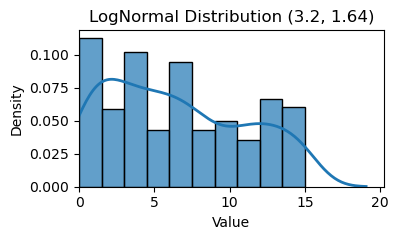

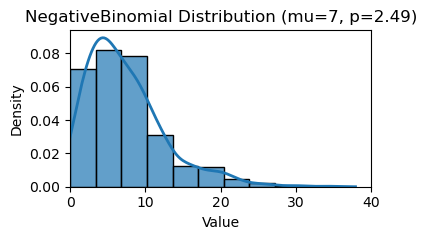

In [ ]:
# Create a helper object for generating epidemiologic distributions
# Point to parent directory Results folder
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
results_dir = os.path.join(parent_dir, 'Results')

process = distribution.Distributions(1000, 1, True, results_dir)

# -----------------------------
# 1. Generation interval distribution
# -----------------------------
# Simulate a lognormal generation-interval distribution,
# then convert it to a normalized discrete probability mass function.
sample = process.lognormal(loc=3.2, scale=1.64, T=15)
generation_interval = process.compute_portion(sample)

# Save the generation interval to a CSV file for later use or inspection
df_generation_interval = pd.DataFrame()
df_generation_interval['time'] = np.arange(len(generation_interval)) + 1
df_generation_interval['pmf'] = generation_interval
df_generation_interval.to_csv(os.path.join(results_dir, 'df_generation_interval.csv'))

# -----------------------------
# 2. Infection-to-admission delay distribution
# -----------------------------
# Recreate the helper object and generate a negative-binomial delay distribution
# for the time between infection and hospital admission.
process = distribution.Distributions(1000, 1, True, results_dir)
sample = process.negative_binomial(mu=7, alpha=2.49, T=55)
admission_interval = process.compute_portion(sample)

# Save the admission delay distribution to CSV
df_admission_interva = pd.DataFrame()
df_admission_interva['time'] = np.arange(len(admission_interval)) + 1
df_admission_interva['pmf'] = admission_interval
df_admission_interva.to_csv(os.path.join(results_dir, 'df_admission_interval.csv'))

### Load Dataset

In [5]:
from spatial_bayes_renewal import (
    ClassicalForecaster,
    SpatialForecaster,
    distribution,
    visualization,
    accuracy
)


84
Index(['Unnamed: 0', 'date', 'Weekly_Encounters',
       'Weekly_Inpatient_Hospitalizations', 'Weekly_ED_Visit',
       'Weekly_Outpatient', 'county', 'county_fips', 'pcr_target_avg_conc',
       'pop', 'state'],
      dtype='object')


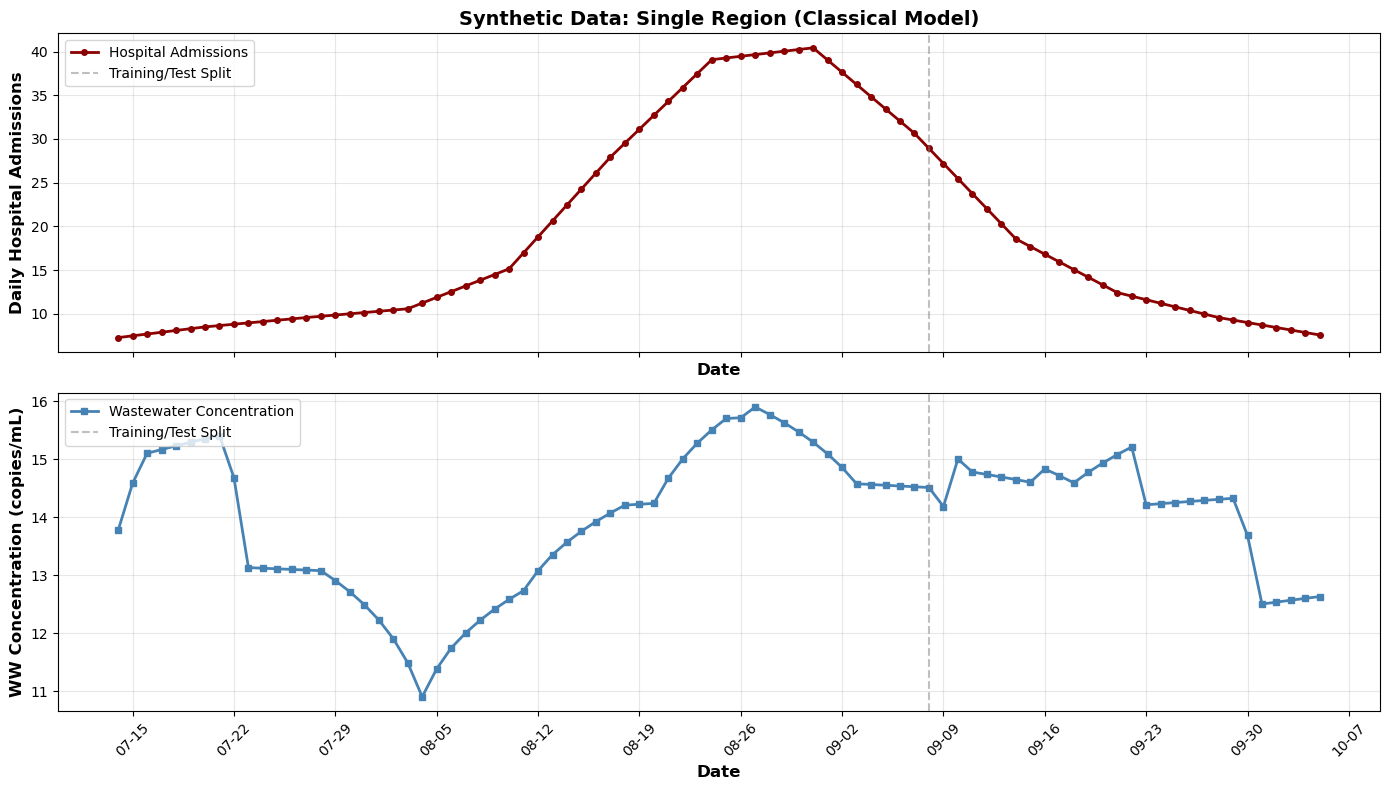

In [ ]:
# Point to parent directory data folder
data_dir = os.path.join(parent_dir, 'data')

df_classical = pd.read_csv(os.path.join(data_dir, 'df_COVID_SC_county.csv'))
df_classical = df_classical[df_classical['county']=='Richland']
df_classical = df_classical[df_classical['date']>='2025-07-14']
df_classical = df_classical[df_classical['date']<'2025-10-06']

print(len(df_classical))

n_train = 7*8
n_test = 7*4
print(df_classical.columns)
df_classical['hosp_obs'] = df_classical['Weekly_Encounters']
df_classical['ww_obs'] = np.log(df_classical['pcr_target_avg_conc'])/np.log(2)

# Create Results/Classcial directory if it doesn't exist
classical_results_dir = os.path.join(results_dir, 'Classcial')
os.makedirs(classical_results_dir, exist_ok=True)

visualization.plot_temporal_data(df_classical['date'].values, df_classical['hosp_obs'].values, df_classical['ww_obs'].values, n_train, save_path=os.path.join(classical_results_dir, 'Data_for_Bayesian.png'), show=True);

## 4. Initialize and Run Classical Forecaster

Build and fit the classical (non-spatial) Bayesian renewal model:

In [7]:
# Split data into training (first 40 days) and test (last 20 days)


df_train_classical = df_classical[:n_train]

# Initialize Classical Forecaster
print("Initializing ClassicalForecaster...")
forecaster_classical = ClassicalForecaster(
    df_data_train=df_train_classical,
    cols_concern=['hosp_obs','ww_obs'], ####['hosp_obs', 'ww_obs']
    n_forecast_points=n_test,  # 4 weeks = 28 days
    data_path='.',
    pop=100000,  # Population size
    Renewal_infection_case='Basic',  # Options: 'Basic', 'Feedback', 'Logistic_S'
    num_samples=100,  # Reduced for faster execution
    num_warmup=75,
    num_chains=1,
    progress_bar=True,
    print_summary=True
)

# Set required parameters
forecaster_classical.gen_int_array = generation_interval
forecaster_classical.inf_hosp_array = admission_interval

# Adjust priors if needed
forecaster_classical.set_I0 = 100
forecaster_classical.set_R0 = 0.5
forecaster_classical.set_P_hosp = 0.1
forecaster_classical.delay_ww = 7


print("✓ ClassicalForecaster initialized")
print(f"  - Training data: {n_train} days")
print(f"  - Forecast horizon: 28 days (4 weeks)")
print(f"  - MCMC: {forecaster_classical.num_samples} samples, {forecaster_classical.num_warmup} warmup, {forecaster_classical.num_chains} chains")

Initializing ClassicalForecaster...
✓ ClassicalForecaster initialized
  - Training data: 56 days
  - Forecast horizon: 28 days (4 weeks)
  - MCMC: 100 samples, 75 warmup, 1 chains


In [8]:
# Run MCMC inference
print("\nRunning MCMC inference (this may take 2-3 minutes)...\n")
samples_classical, predictions_classical = forecaster_classical.run_mcmc()

print("\n✓ MCMC inference completed")
print(f"\nPosterior samples summary:")
for key in samples_classical.keys():
    val = samples_classical[key]
    print(f"  - {key}: shape={val.shape}")


Running MCMC inference (this may take 2-3 minutes)...



sample: 100%|██████████| 175/175 [00:42<00:00,  4.08it/s, 63 steps of size 3.75e-02. acc. prob=0.88]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
          I0    490.95    103.05    478.27    328.06    625.60     12.15      1.05
      P_hosp      0.11      0.01      0.11      0.09      0.12     88.31      1.00
          R0      1.18      0.07      1.20      1.09      1.28     10.52      1.04
     beta_ww      0.00      0.05      0.01     -0.11      0.05     12.08      1.03
      k_hosp     46.98     34.57     36.86      1.71     97.69      7.73      0.99
 rw_steps[0]      0.00      0.00      0.00     -0.01      0.01    329.76      0.99
 rw_steps[1]      0.00      0.00      0.00     -0.00      0.01    209.98      1.00
 rw_steps[2]      0.00      0.00      0.00     -0.01      0.01    102.89      0.99
 rw_steps[3]      0.00      0.01      0.00     -0.01      0.01    166.61      1.00
 rw_steps[4]      0.00      0.00      0.00     -0.00      0.01    312.10      0.99
 rw_steps[5]      0.00      0.00      0.00     -0.01      0.01    142.75      1.00
 rw

## 5. Plot Classical Model: 4-Week Hospital Admissions Forecast

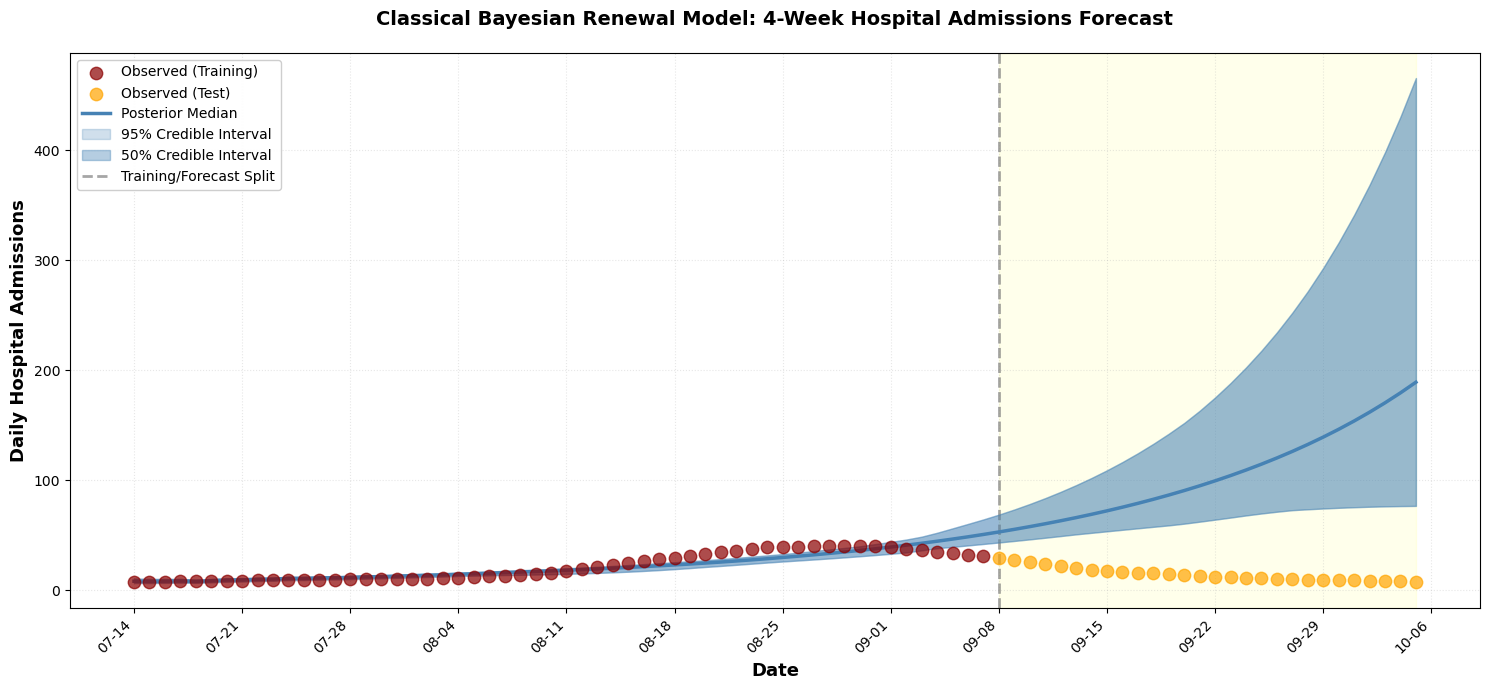

In [ ]:
import importlib
importlib.reload(visualization)

# Extract predictions
H_pred = predictions_classical['H_t']  # shape: (samples, time)

n_previous = forecaster_classical.n_previous_points
T = n_train + n_test  

H_mean = np.mean(H_pred, axis=0)[-T:]
H_median = np.median(H_pred, axis=0)[-T:]
H_lower = np.percentile(H_pred, 2.5, axis=0)[-T:]
H_upper = np.percentile(H_pred, 97.5, axis=0)[-T:]

results_df = pd.DataFrame({
    "date": df_classical["date"].values[0:T],
    "hosp_obs": df_classical['hosp_obs'].values[0:T],
    "pred_mean": H_mean,
    "pred_median": H_median,
    "pred_lower_95": H_lower,
    "pred_upper_95": H_upper
})

visualization.plot_forecast(
    dates=results_df['date'].values,
    hosp_obs=results_df['hosp_obs'].values,
    h_center=results_df['pred_mean'].values,
    h_lower=results_df['pred_lower_95'].values,
    h_upper=results_df['pred_upper_95'].values,
    n_train=n_train,
    n_test=n_test,
    save_path=os.path.join(classical_results_dir, 'Forecast_of_Bayesian.png'),
    show=False
)

In [10]:
H_pred.shape

(100, 84)

────────────────────────────────────────────────────
week 0 true_weekly: 167.2142857142857 pred_weekly: 410.0282
  Proportional Accuracy (PA) : 0.4125  
  RMSE                       : 243.8139
  DTW Distance               : 243.8139
────────────────────────────────────────────────────
week 1 true_weekly: 106.42857142857144 pred_weekly: 539.53876
  Proportional Accuracy (PA) : 0.2028  
  RMSE                       : 434.1102
  DTW Distance               : 434.1102
────────────────────────────────────────────────────
week 2 true_weekly: 76.57142857142857 pred_weekly: 720.6393
  Proportional Accuracy (PA) : 0.1110  
  RMSE                       : 645.0679
  DTW Distance               : 645.0679
────────────────────────────────────────────────────
week 3 true_weekly: 60.0 pred_weekly: 957.0829
  Proportional Accuracy (PA) : 0.0665  
  RMSE                       : 898.0829
  DTW Distance               : 898.0829


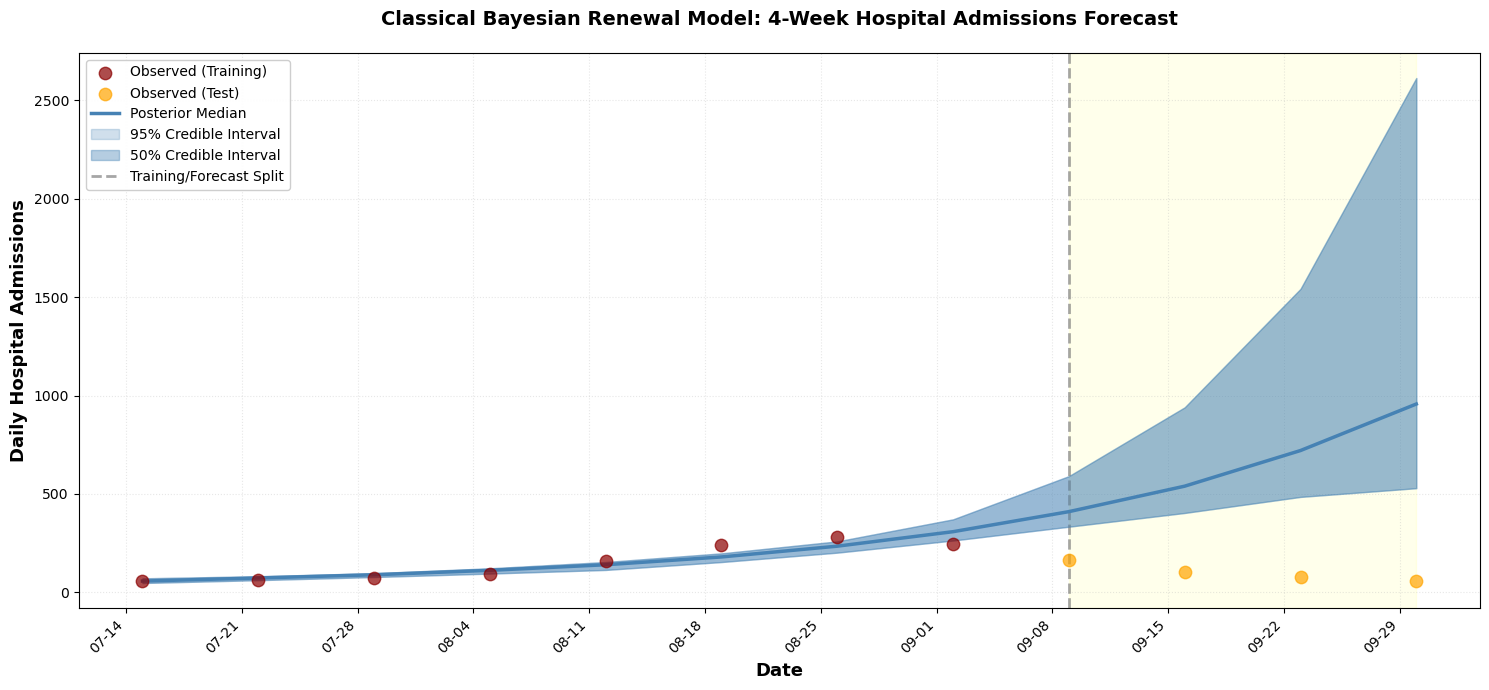

In [ ]:
import importlib
importlib.reload(accuracy)

results_df["date"] = pd.to_datetime(results_df["date"], errors="coerce")

weekly_results = (
    results_df
    .set_index("date")
    .resample("W-SUN")
    .agg({
        "hosp_obs": "sum",
        "pred_mean": "sum",
        "pred_median": "sum",
        "pred_lower_95": "sum",
        "pred_upper_95": "sum"
    })
    .reset_index()
)

# Last 4 weeks = forecast period
true_weekly   = weekly_results['hosp_obs'].values[-4:]
pred_weekly   = weekly_results['pred_median'].values[-4:]

control_num=5
for idx, (i, j) in enumerate(zip(true_weekly, pred_weekly)):
    pa, rmse, dtw_dist = accuracy.measure_accuracy([i+control_num], [j+control_num])
    print("────────────────────────────────────────────────────")
    print('week',idx,'true_weekly:', i+1, 'pred_weekly:', j)
    print(f"  Proportional Accuracy (PA) : {pa:.4f}  ")
    print(f"  RMSE                       : {rmse:.4f}")
    print(f"  DTW Distance               : {dtw_dist:.4f}")
   

weekly_results['date'] = weekly_results['date'] - pd.Timedelta(days=5)

visualization.plot_forecast(
    dates=weekly_results['date'].values,
    hosp_obs=weekly_results['hosp_obs'].values,
    h_center=weekly_results['pred_median'].values,
    h_lower=weekly_results['pred_lower_95'].values,
    h_upper=weekly_results['pred_upper_95'].values,#
    n_train=len(weekly_results) - 4,
    n_test=4,
    save_path=os.path.join(classical_results_dir, 'Weekly_Forecast_of_Bayesian.png'),
    show=False
)

## 7. Plot Reproduction Number Estimates

In [40]:

R_t_samples=predictions_classical['R_t']
R_mean   = np.mean(R_t_samples, axis=0)[10:]
R_median = np.median(R_t_samples, axis=0)[10:]
R_lower  = np.percentile(R_t_samples, 2.5,  axis=0)[10:]
R_upper  = np.percentile(R_t_samples, 97.5, axis=0)[10:]
R_q25    = np.percentile(R_t_samples, 25,   axis=0)[10:]
R_q75    = np.percentile(R_t_samples, 75,   axis=0)[10:]
print(len(R_mean))

84


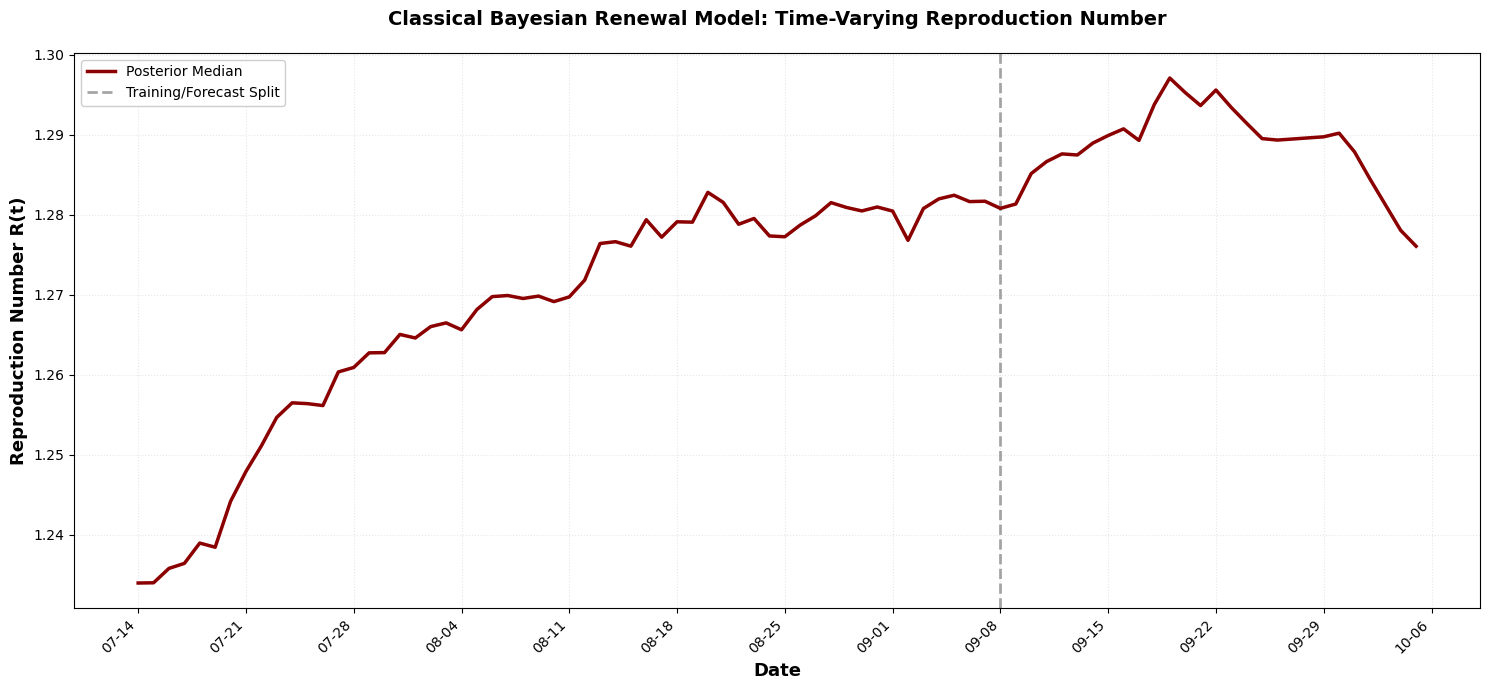

In [ ]:
# Build date range for training + forecast period
forecast_dates = pd.date_range(
    start=pd.to_datetime(df_classical['date'].values[0]),
    periods=n_train + n_test,
    freq='D',
)

visualization.plot_reproduction_number(
    dates=forecast_dates,
    r_center=R_median,
    r_lower=R_lower,
    r_upper=R_upper,
    n_train=n_train,
    save_path=os.path.join(classical_results_dir, 'Rt_of_Bayesian.png'),
    show=False,
)